# Galaxy Evolution Simulator

In [1]:
import numpy as np 
import astropy.units as u
import matplotlib.pyplot as plt

The class below provides everything to simulate + plot a galaxy's evolution.
Initialize with: 
- timestep `dt`
- starting gas mass `m_gas`
- star formation extinction time `t_ex`
- gas infall stopping time `t_stop`
- gas infall rate `infall_rate`
- metals yielded from dead stars `z_yield`

Then use `galaxy.evolution()` to run the simulation, and `galaxy.plot_everything()` for plots

In [2]:
class galaxy:
    def __init__(self, dt, m_gas, t_ex, t_stop, infall_rate, z_yield):
        """initial conditions and parameters
        
        Parameters
        ----------
            dt: `float`
                timestep size (Gyr)
            m_gas: `int`
                initial gas mass (Msun)
            t_ex: `int | float`
                exhaustion timescale for star formation (Gyr)
            t_stop: `int | float`
                time that gas infall stops (Gyr)
            infall_rate: `int | float`
                rate of gas infall into galaxy (Msun / yr)
            z_yield: `float`
                rate of star death (must be <1)
            """
        
        # timesteps and time array
        self.dt = dt * u.Gyr
        self.timesteps = np.arange(14, step=dt)                   # timesteps
        # masses of gas and stars
        self.mass_gas = np.zeros_like(self.timesteps) * u.Msun    # gas mass (Msun)
        self.mass_gas[0] = m_gas * u.Msun                         # initial mass
        self.mass_star = np.zeros_like(self.mass_gas)             # stellar mass (Msun)
        self.mass_infall = np.zeros_like(self.mass_gas)           # mass of infalling gas
        # metallicity
        self.z_gas = np.zeros_like(self.timesteps)                # average gas metallicity
        self.z_stars = np.zeros_like(self.timesteps)              # average star metallicity
        # star formation rate, controlled by extinction time
        self.sfr = np.empty_like(self.timesteps) * (u.Msun / u.yr)  # SFR (Msun / yr)
        self.t_ex = t_ex * u.Gyr 
        self.factor = 1 / self.t_ex.to(u.yr)
        # apply units
        self.timesteps *= u.Gyr
        self.t_stop = t_stop * u.Gyr 
        self.infall_rate = infall_rate * (u.Msun / u.yr)
        self.z_yield = z_yield 
        pass
    
    def evolution(self):
        """runs through galaxy evolution simulation"""
        for i, time in enumerate(self.timesteps):
            if i == 0:
                self.sfr[i] = self.mass_gas[i] * self.factor
                continue
            
            # stars dying removes star mass, adds gas mass
            # note: this could be controlled by its own parameter instead of SFR...
            dead_stars = self.z_yield * self.sfr[i-1] * self.dt
            if self.mass_star[i-1] == 0:
                dead_stars = 0 * u.Msun
            self.mass_star[i] = self.mass_star[i-1] - dead_stars
            self.mass_gas[i] = self.mass_gas[i-1] + dead_stars

            # new gas added via infall
            if time <= self.t_stop:
                self.mass_infall[i] = self.infall_rate * self.dt
            self.mass_gas[i] += self.mass_infall[i]

            # SFR this timestep based on existing gas mass
            self.sfr[i] = self.mass_gas[i] * self.factor
            new_stars = self.sfr[i-1] * self.dt

            # only make new stars if there is enough gas for it
            if self.mass_gas[i-1] > new_stars:
                self.mass_star[i] += new_stars
                self.mass_gas[i]  -= new_stars

            # gas metallicity = (prev metallicity * (prev gas - new stars) + dead star mass) / total current gas mass
            self.z_gas[i] = (self.z_gas[i-1] * (self.mass_gas[i-1] - new_stars) + dead_stars) / self.mass_gas[i]
            # star metallicity = (prev metallicity * prev stars + new stars * prev gas metallicity) / total current star mass
            self.z_stars[i] = (self.z_stars[i-1] * self.mass_star[i-1] + new_stars*self.z_gas[i-1]) / self.mass_star[i]
            
    def plot_everything(self, maxtime=3.0):
        """plots stellar mass, gas mass, star formation, and metallicity over time
        
        Parameters
        ----------
            maxtime: `int | float`
                maximum time to plot up to (Gyr, default = 3)
        """
        
        fig, ax = plt.subplots(1, 3, figsize=(12,4), sharex=True)
        timerange = self.timesteps.value <= maxtime

        # mass evolution
        ax[0].plot(self.timesteps[timerange], self.mass_gas[timerange], label="gas mass")
        ax[0].plot(self.timesteps[timerange], self.mass_star[timerange], label="stellar mass")
        ax[0].set(xlabel="Time (Gyr)", ylabel="Mass (Msun)", title=f"Mass evolution")
        ax[0].legend()
        ax[0].grid(True)
        
        # metallicity evolution
        ax[1].plot(self.timesteps[timerange], self.z_gas[timerange], label="gas metallicity")
        ax[1].plot(self.timesteps[timerange], self.z_stars[timerange], label="stellar metallicity")
        ax[1].set(xlabel="Time (Gyr)", ylabel="Metallicity Z", title=f"Metallicity evolution")
        ax[1].legend()
        ax[1].grid(True)
        
        # star formation evolution
        ax[2].plot(self.timesteps[timerange], self.sfr[timerange])
        ax[2].set(xlabel="Time (Gyr)", ylabel="SFR (Msun/yr)", title="Star formation rate")
        ax[2].grid(True)
        
        plt.tight_layout()
        plt.show()
        

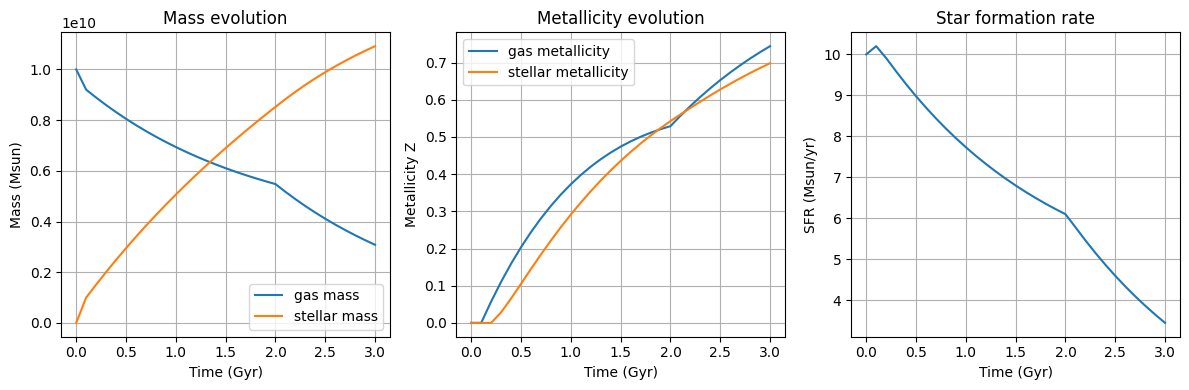

In [3]:
gal_test = galaxy(0.1, 1e10, 1, 2, 2, 0.5)
gal_test.evolution()
gal_test.plot_everything()

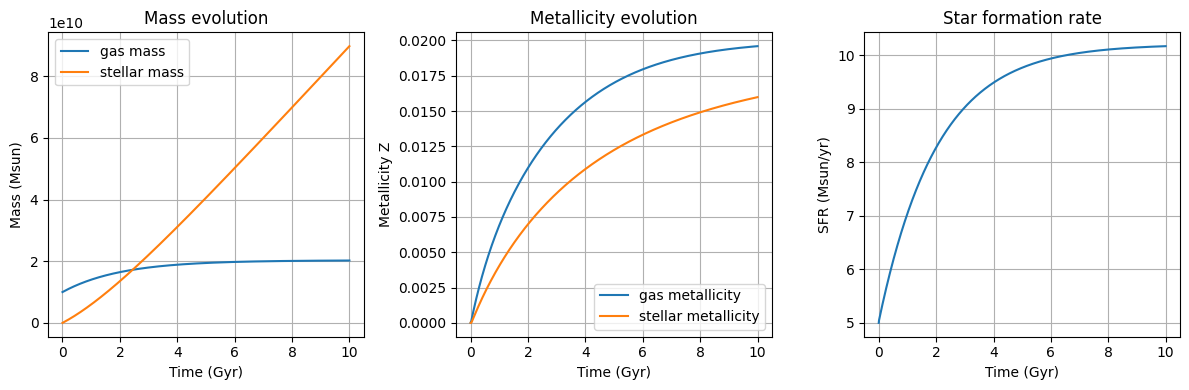

In [4]:
# never-ending gas infall
workshop_3 = galaxy(0.01, 1e10, 2, 14, 10, 0.02)
workshop_3.evolution()
workshop_3.plot_everything(10)

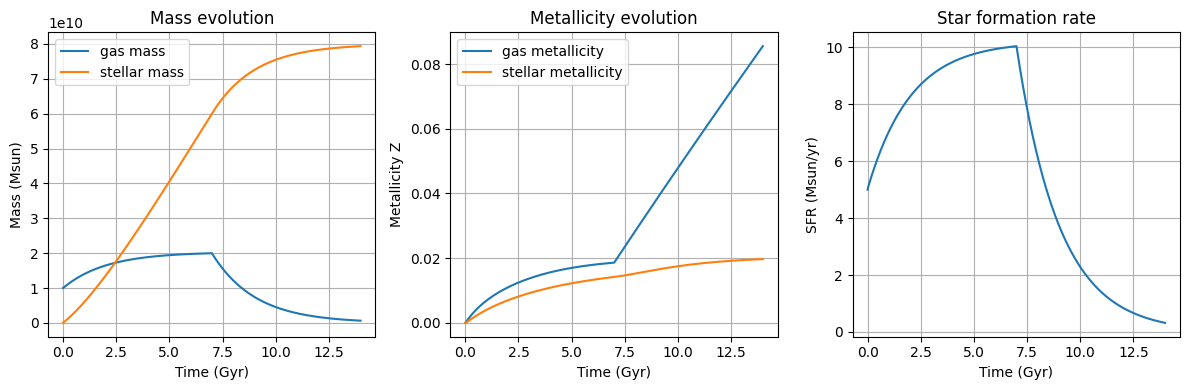

In [5]:
# gas infall stops after 7 Gyr
workshop_4 = galaxy(0.01, 1e10, 2, 7, 10, 0.02)
workshop_4.evolution()
workshop_4.plot_everything(14)

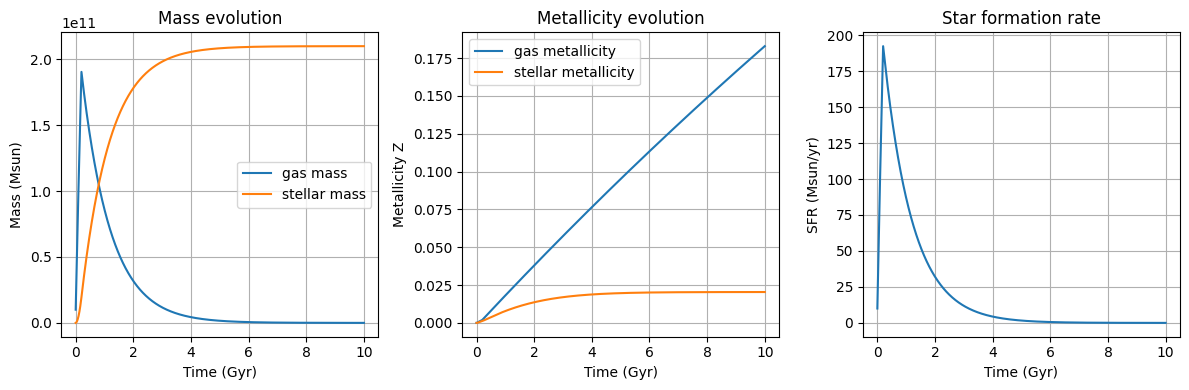

In [6]:
# "elliptical galaxy" - infall rate of 1000 Msun stopping after 200 Myr
workshop_6 = galaxy(0.01, 1e10, 1, 0.2, 1000, 0.02)
workshop_6.evolution()
workshop_6.plot_everything(10)